In [1]:
from evogym import sample_robot
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import matplotlib.pyplot as plt
from matplotlib import animation
import gymnasium as gym
import evogym.envs
from evogym import sample_robot
from evogym.utils import get_full_connectivity
from evogym import is_connected, has_actuator
from tqdm import tqdm
from datetime import datetime
import json
import os
import imageio

/opt/anaconda3/envs/evo/lib/python3.10/site-packages/evogym/envs/base.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Base functions

In [2]:
class Network(nn.Module):
    def __init__(self, n_in, h_size, n_out):
        super().__init__()
        self.fc1 = nn.Linear(n_in, h_size)
        self.fc2 = nn.Linear(h_size, h_size)
        self.fc3 = nn.Linear(h_size, n_out)
 
        self.n_out = n_out

    def reset(self):
        pass
    
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)
        x = F.relu(x)

        x = self.fc3(x)
        return x

class Agent:
    def __init__(self, Net, config, genes = None):
        self.config = config
        self.Net = Net
        self.model = None
        self.fitness = None

        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu")

        self.make_network()
        if genes is not None:
            self.genes = genes

    def __repr__(self):  # pragma: no cover
        return f"Agent {self.model} > fitness={self.fitness}"

    def __str__(self):  # pragma: no cover
        return self.__repr__()

    def make_network(self):
        n_in = self.config["n_in"]
        h_size = self.config["h_size"]
        n_out = self.config["n_out"]
        self.model = self.Net(n_in, h_size, n_out).to(self.device).double()
        return self

    @property
    def genes(self):
        if self.model is None:
            return None
        with torch.no_grad():
            params = self.model.parameters()
            vec = torch.nn.utils.parameters_to_vector(params)
        return vec.cpu().double().numpy()

    @genes.setter
    def genes(self, params):
        if self.model is None:
            self.make_network()
        assert len(params) == len(
            self.genes), "Genome size does not fit the network size"
        if np.isnan(params).any():
            raise
        a = torch.tensor(params, device=self.device)
        torch.nn.utils.vector_to_parameters(a, self.model.parameters())
        self.model = self.model.to(self.device).double()
        self.fitness = None
        return self

    def mutate_ga(self):
        genes = self.genes
        n = len(genes)
        f = np.random.choice([False, True], size=n, p=[1/n, 1-1/n])
        
        new_genes = np.empty(n)
        new_genes[f] = genes[f]
        noise = np.random.randn(n-sum(f))
        new_genes[~f] = noise
        return new_genes

    def act(self, obs):
        # continuous actions
        with torch.no_grad():
            x = torch.tensor(obs).double().unsqueeze(0).to(self.device)
            actions = self.model(x).cpu().detach().numpy()
        return actions


In [3]:
base = np.array([
    [4, 0, 4, 1, 4],
    [3, 0, 4, 0, 3],
    [4, 0, 4, 2, 0],
    [4, 3, 4, 4, 2],
    [0, 4, 1, 0, 0]
    ])

def make_env(env_name, seed=None, robot=None, **kwargs):
    if robot is None: 
        env = gym.make(env_name)
    else:
        connections = get_full_connectivity(robot)
        env = gym.make(env_name, body=robot)
    env.robot = robot
    if seed is not None:
        env.seed(seed)
        
    return env

def evaluate(agent, env, max_steps=500, render=False):
    obs, i = env.reset()
    agent.model.reset()
    reward = 0
    steps = 0
    done = False
    while not done and steps < max_steps:
        if render:
            env.render()
        action = agent.act(obs)
        obs, r, done, trunc, _ = env.step(action)
        reward += r
        steps += 1
    return reward

def get_cfg(env_name, robot=None):
    env = make_env(env_name, robot=base)
    cfg = {
        "n_in": env.observation_space.shape[0],
        "h_size": 32,
        "n_out": env.action_space.shape[0],
    }
    env.close()
    return cfg

def mp_eval(a, cfg):
    env = make_env(cfg["env_name"], robot=cfg["robot"])
    fit = evaluate(a, env, max_steps=cfg["max_steps"])
    env.close()
    return fit

In [4]:
def save_solution(a, cfg, base_dir="results"):
    save_cfg = {}
    for i in ["env_name", "robot", "n_in", "h_size", "n_out"]:
        assert i in cfg, f"{i} not in config"
        save_cfg[i] = cfg[i]
        
    save_cfg["robot"] = cfg["robot"].tolist()
    save_cfg["genes"] = a.genes.tolist()
    save_cfg["fitness"] = float(a.fitness)

    date_heure = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    env_name = cfg["env_name"]
    target_dir = os.path.join(base_dir, f"{env_name}_{date_heure}")
    os.makedirs(target_dir, exist_ok=True) 
    fitness_str = f"{save_cfg['fitness']:.2f}" 
    filename = f"{fitness_str}.json"
    full_path = os.path.join(target_dir, filename)
    
    with open(full_path, "w") as f:
        json.dump(save_cfg, f, indent=4) 
    return save_cfg

def load_solution(name):
    with open(name, "r") as f:
        cfg = json.load(f)
    cfg["robot"] = np.array(cfg["robot"])
    cfg["genes"] = np.array(cfg["genes"])
    a = Agent(Network, cfg, genes=cfg["genes"])
    a.fitness = cfg["fitness"]
    return a

In [5]:
def generate_valid_robot_shape(width=5, height=5):
    body = np.random.randint(0, 5, size=(width, height))
    while not (is_connected(body) and has_actuator(body)):
        body = np.random.randint(0, 5, size=(width, height))
    return body

# Evolution

In [6]:
thrower = np.array([
    [4, 0, 4, 1, 4],
    [3, 0, 4, 0, 3],
    [4, 0, 4, 2, 0],
    [4, 3, 4, 4, 2],
    [0, 4, 1, 0, 0]
    ])

env_name = 'Thrower-v0'
robot = thrower

cfg = get_cfg(env_name, robot)
a = Agent(Network, cfg)

Using Evolution Gym Simulator v2.2.5


### Evolution Strategy

In [7]:
def ES(config):
    cfg = get_cfg(config["env_name"], robot=config["robot"]) # Get network dims
    cfg = {**config, **cfg} # Merge configs
    
    # Update weights
    mu = cfg["mu"]
    w = np.array([np.log(mu + 0.5) - np.log(i)
                          for i in range(1, mu + 1)])
    w /= np.sum(w)
    
    env = make_env(cfg["env_name"], robot=cfg["robot"])

    # Center of the distribution
    elite = Agent(Network, cfg)
    elite.fitness = -np.inf
    theta = elite.genes
    d = len(theta)

    fits = []
    total_evals = []

    bar = tqdm(range(cfg["generations"]))
    for gen in bar:
        population = []
        for i in range(cfg["lambda"]):
            genes = theta + np.random.randn(len(theta)) * cfg["sigma"]
            ind = Agent(Network, cfg, genes=genes)
            # ind.fitness = evaluate(ind, env, max_steps=cfg["max_steps"])
            population.append(ind)

        # with Pool(processes=len(population)) as pool:
        #     pop_fitness = pool.starmap(mp_eval, [(a, cfg) for a in population])
        
        pop_fitness = [evaluate(a, env, max_steps=cfg["max_steps"]) for a in population]
        
        for i in range(len(population)):
            population[i].fitness = pop_fitness[i]

        # sort by fitness
        inv_fitnesses = [- f for f in pop_fitness]
        # indices from highest fitness to lowest
        idx = np.argsort(inv_fitnesses)
        
        step = np.zeros(d)
        for i in range(mu):
            # update step
            step = step + w[i] * (population[idx[i]].genes - theta)
        # update theta
        theta = theta + step * cfg["lr"]

        if pop_fitness[idx[0]] > elite.fitness:
            elite.genes = population[idx[0]].genes
            elite.fitness = pop_fitness[idx[0]]

        fits.append(elite.fitness)
        total_evals.append(len(population) * (gen+1))

        bar.set_description(f"Best: {elite.fitness}")
        
    env.close()
    plt.plot(total_evals, fits)
    plt.xlabel("Evaluations")
    plt.ylabel("Fitness")
    plt.show()
    return elite

Best: 0.46457881956644065:  37%|███▋      | 37/100 [04:58<08:30,  8.10s/it]

SIMULATION UNSTABLE... TERMINATING


Best: 0.46457881956644065:  39%|███▉      | 39/100 [05:14<08:02,  7.91s/it]

SIMULATION UNSTABLE... TERMINATING


Best: 0.46457881956644065:  41%|████      | 41/100 [05:28<07:26,  7.57s/it]

...

Best: 0.8580179442815501:  98%|█████████▊| 98/100 [12:56<00:15,  7.60s/it]

SIMULATION UNSTABLE... TERMINATING
SIMULATION UNSTABLE... TERMINATING


Best: 0.8580179442815501:  99%|█████████▉| 99/100 [13:02<00:07,  7.09s/it]

SIMULATION UNSTABLE... TERMINATING
SIMULATION UNSTABLE... TERMINATING


Best: 0.8580179442815501: 100%|██████████| 100/100 [13:09<00:00,  7.90s/it]


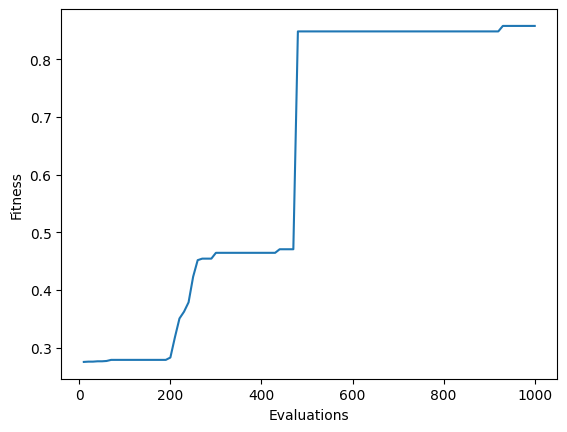

0.8580179442815501

In [8]:
config = {
    "env_name": "Thrower-v0",
    "robot": thrower,
    "generations": 100, 
    "lambda": 10,  # Population size
    "mu": 5, # Parents pop size
    "sigma": 0.1, # mutation std
    "lr": 0.5, # Learning rate
    "max_steps": 500, 
}

a = ES(config)
a.fitness

In [9]:
cfg = {**config, **cfg}
save_solution(a, cfg)

{'env_name': 'Thrower-v0',
 'robot': [[4, 0, 4, 1, 4],
  [3, 0, 4, 0, 3],
  [4, 0, 4, 2, 0],
  [4, 3, 4, 4, 2],
  [0, 4, 1, 0, 0]],
 'n_in': 74,
 'h_size': 32,
 'n_out': 13,
 'genes': [-0.04529337650728948,
  0.1711360353062488,
  -0.12406245339125745,
  0.31576475814922866,
  0.2921001884549189,
  -0.21879251224194896,
  0.08690236507194615,
  -0.21508592421220052,
  -0.1923343188603956,
  0.3742408237770772,
  0.03922256215125367,
  0.027196620762156537,
  -0.41904076537770696,
  0.10238984303464882,
  -0.08315206747782945,
  0.3166188021528331,
  0.537782603052491,
  -0.4459907476154602,
  -0.6202298252011615,
  -0.3428426174218819,
  -0.051919146534833205,
  0.13469626500814516,
  0.08930821427824887,
  -0.18946745567349843,
  -0.22248843926046333,
  -0.213927466140772,
  0.16631920584682547,
  -0.24310702519766847,
  0.10913986595176105,
  -0.034796360131699094,
  -0.1845330080861899,
  -0.2110617107269252,
  -0.28823640752969204,
  0.037211587363208926,
  -0.20440054494473808,
  